DSC550-T302<br>
Week 4 Assignment<br>
Jeremy Barton

In this notebook a linear regression modell will be built to predict fuel efficiency (mpg) of automobiles.

This analysis will use th following dataset from Kaggle: https://www.kaggle.com/datasets/uciml/autompg-dataset?resource=download

In [28]:
# Imports and Preprocessing
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

1) Load the data as a Pandas data frame and ensure that it imported correctly.

In [3]:
mpg_df = pd.read_csv("auto-mpg.csv") # create object for mpg dataframe
mpg_df.head(5)                       #      from autp-mpg.csv file

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


2) Begin by prepping the data for modeling:

a. Remove the car name column.

In [4]:
mpg_df = mpg_df.drop(["car name"], axis=1)

In [5]:
mpg_df.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


b. The horsepower column values likely imported as a string data type. Figure out why and replace any strings with the column mean.

In [6]:
# using .dtypes() to explore the datatype
#   of horsepower
mpg_df["horsepower"].dtypes

<StringDtype(storage='python', na_value=nan)>

From the below output, it looks like the `horsepower` field is a string type because there is a question mark on rows that horsepower was not recorded for.

In [7]:
# select non-numerics from the "horsepower" field
non_num = mpg_df[pd.to_numeric(mpg_df["horsepower"], errors="coerce").isna()]
non_num["horsepower"]

32     ?
126    ?
330    ?
336    ?
354    ?
374    ?
Name: horsepower, dtype: str

Before doing so, the column will need to be converted to numeric, and anything that isnt is NaN.

In [8]:
# convert to numeric (non-numeric become NaN)
mpg_df["horsepower"] = pd.to_numeric(mpg_df["horsepower"], errors="coerce")

Calculating the mean with `.mean()` 

In [9]:
# calculate mean (ignores NaN automatically)
mean_hp = mpg_df["horsepower"].mean()

# fill NaN values with the mean
mpg_df["horsepower"].fillna(mean_hp, inplace=True)

/tmp/ipykernel_15144/3293264889.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  mpg_df["horsepower"].fillna(mean_hp, inplace=True)


0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: horsepower, Length: 398, dtype: float64

Create dummy variables for the origin column.

What unique values are in `origin`?

In [10]:
mpg_df['origin'].value_counts()

origin
1    249
3     79
2     70
Name: count, dtype: int64

Set all origin values to "UNKNOWN".

In [11]:
mpg_df['origin'] = "UNKNOWN"
mpg_df['origin'].value_counts()

origin
UNKNOWN    398
Name: count, dtype: int64

3) Create a correlation coefficient matrix and/or visualization. Are there features highly correlated with mpg?

In [12]:
corr = mpg_df.corr(numeric_only=True) # this setting insures only numeric values return in the matrix

Configuring the plot.

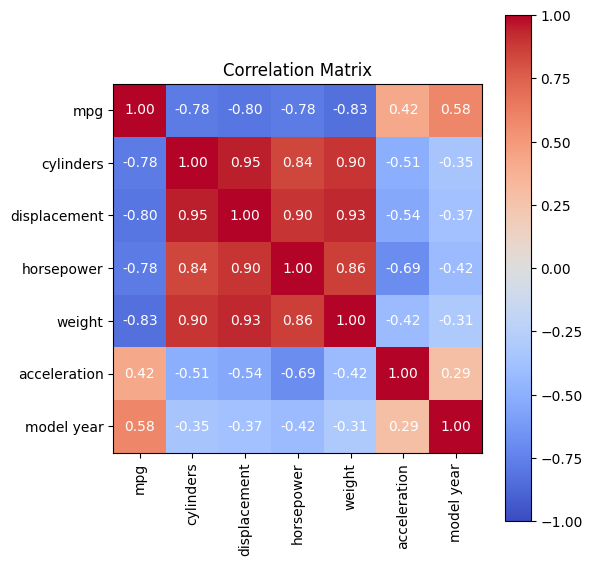

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(corr, cmap='coolwarm', interpolation='none', vmin=-1, vmax=1)
plt.colorbar()

# labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# add mpg data
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', color='white')

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In a correlation matrix, the closer a value is to +1 or -1, the more highly or negatively correlated values that the two values of that intersect are. In the matrix above, the relationship with the highest is  with `displacement` compared with `cylinders`, `horsepower` and `weight`. This makes logical sense because the heavier a vehicle is, the more horsepower is required to move it at comparable speed with cars of lighter weight classes.

Whereas the relationships with the lowest correlation were `acceleration` and `weight` compared with `model year`. Nothing surprises me about these findings either. No matter the model year, due to safety regulations the acceleration should not change with model year. Weight should also stay consistent through the years as technology negatively affecting a vehicles weight may have plataeued.

4) Plot mpg versus weight. Analyze this graph and explain how it relates to the corresponding correlation coefficient.

`seaborn` and `matplotlib` will be used.

Text(0.5, 1.0, 'Vehicle Weight vs MPG')

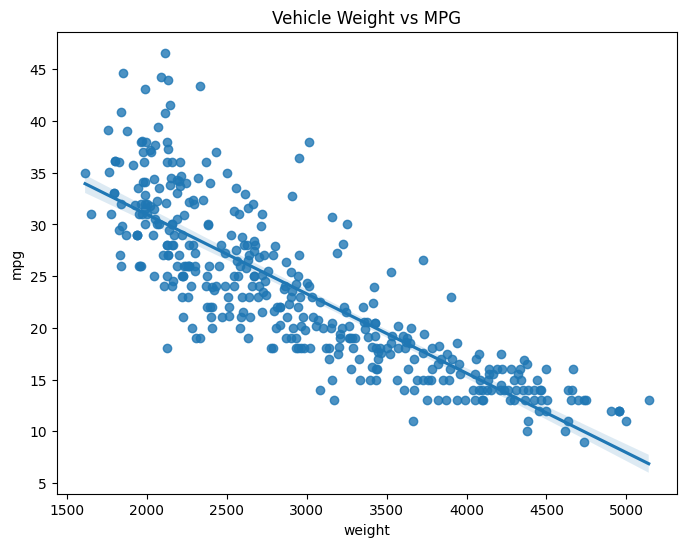

In [25]:
plt.figure(figsize=(8,6)) # blot size
sns.regplot(x='weight', y='mpg', data=mpg_df)

plt.title('Vehicle Weight vs MPG')

In the correlation matrix, `Weight` and `MPG` showed high negative correlation at -0.83. The linear structure of the scatter plot moving downward shows just <i>how</i> these two variables are negatively correlated.

As a comparison, the below plot shows `Acceleration` vs `Model Year` which has a weak positive correlation of -0.29. Notice how the dots don't fit to the linear line at all.

For the data, this means we can confirm the low correlation between these two variables.

Text(0.5, 1.0, 'Acceleration vs Model Year')

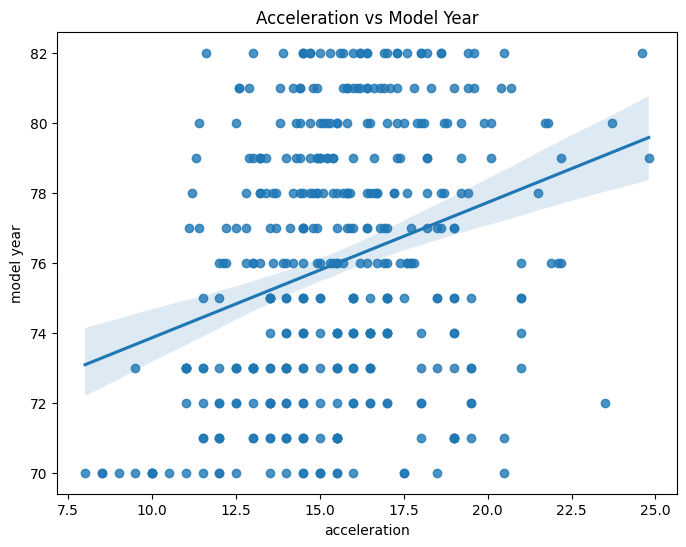

In [27]:
plt.figure(figsize=(8,6)) # blot size
sns.regplot(x='acceleration', y='model year', data=mpg_df)

plt.title('Acceleration vs Model Year')

5. Randomly split the data into 80% training data and 20% test data, where your target is mpg.

In [ ]:
# create training and test sets
x_train, x_test, y_train, y_test = train_test_split(mpg_df, mpg_df['mpg'], test_size=0.1, random_state=1)

Let's explore the shapes of each to understand the size of what we train the data on vs what the target is or data to be predicted.

In [ ]:

y_train.shape

(40,)